<a href="https://colab.research.google.com/github/ananthiananthi76999-bit/Project-1/blob/main/E_Commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving sales_data.csv to sales_data.csv
User uploaded file "sales_data.csv" with length 868 bytes


In [3]:
import pandas as pd
df=pd.read_csv("sales_data.csv")
df

,Id,Product,Category,Quantity,Price,Date
0,101,Phone,Electronics,2,15000,2026-01-10
1,102,Shirt,Clothing,3,1000,2026-02-15
2,103,Laptop,Electronics,1,50000,2026-03-05
3,104,Rice,Grocery,5,500,2026-01-20
4,116,Saree,Clothing,2,4000,2026-08-05
5,106,TV,Electronics,1,30000,NaN
6,107,Watch,Accessories,2,3000,2026-04-05
7,108,Bag,Accessories,3,1500,2026-04-15
8,109,Milk,Grocery,4,60,2026-05-01
9,110,Bread,Grocery,5,40,2026-05-03


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id          0
Product     0
Category    0
Quantity    0
Price       0
Date        1
dtype: int64


In [5]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
2


In [7]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df

,Id,Product,Category,Quantity,Price,Date
0,101,Phone,Electronics,2,15000,2026-01-10
1,102,Shirt,Clothing,3,1000,2026-02-15
2,103,Laptop,Electronics,1,50000,2026-03-05
3,104,Rice,Grocery,5,500,2026-01-20
4,116,Saree,Clothing,2,4000,2026-08-05
6,107,Watch,Accessories,2,3000,2026-04-05
7,108,Bag,Accessories,3,1500,2026-04-15
8,109,Milk,Grocery,4,60,2026-05-01
9,110,Bread,Grocery,5,40,2026-05-03
10,111,Headphones,Electronics,2,2500,2026-06-10


In [8]:
df['total']=df['Quantity']*df['Price']
df

,Id,Product,Category,Quantity,Price,Date,total
0,101,Phone,Electronics,2,15000,2026-01-10,30000
1,102,Shirt,Clothing,3,1000,2026-02-15,3000
2,103,Laptop,Electronics,1,50000,2026-03-05,50000
3,104,Rice,Grocery,5,500,2026-01-20,2500
4,116,Saree,Clothing,2,4000,2026-08-05,8000
6,107,Watch,Accessories,2,3000,2026-04-05,6000
7,108,Bag,Accessories,3,1500,2026-04-15,4500
8,109,Milk,Grocery,4,60,2026-05-01,240
9,110,Bread,Grocery,5,40,2026-05-03,200
10,111,Headphones,Electronics,2,2500,2026-06-10,5000


In [9]:
top_products=df.groupby('Product')['total'].sum().sort_values(ascending=False)
print("Top Selling Products:")
print(top_products)

Top Selling Products:
Product
Laptop          50000
Phone           30000
Saree            8000
Watch            6000
Headphones       5000
Bag              4500
Jacket           3500
Sandals          3000
Shirt            3000
Rice             2500
Perfume          2500
Mouse            1600
Keyboard         1200
Charger          1000
Mobile Cover      800
Oil               600
Milk              240
Bread             200
Name: total, dtype: int64


In [10]:
print(df.columns)

Index(['Id', 'Product', 'Category', 'Quantity', 'Price', 'Date', 'total'], dtype='object')


In [11]:
df['Date']=pd.to_datetime(df['Date'])
monthly_sales=df.groupby(df['Date'].dt.month)['total'].sum()
print("Monthly Sales Trends:")
print(monthly_sales)

Monthly Sales Trends:
Date
1    32500
2     3000
3    50000
4    10500
5      440
6     8500
7     3600
8     9600
9     5500
Name: total, dtype: int64


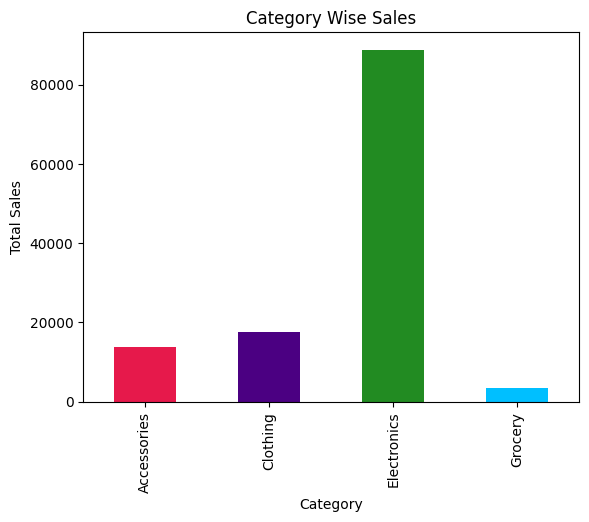

In [12]:
import matplotlib.pyplot as plt
category_sales = df.groupby('Category')['total'].sum()
dark_custom_colors = ['#e6194b', '#4b0082', '#228b22', '#00bfff']
category_sales.plot(kind='bar', color=dark_custom_colors)
plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

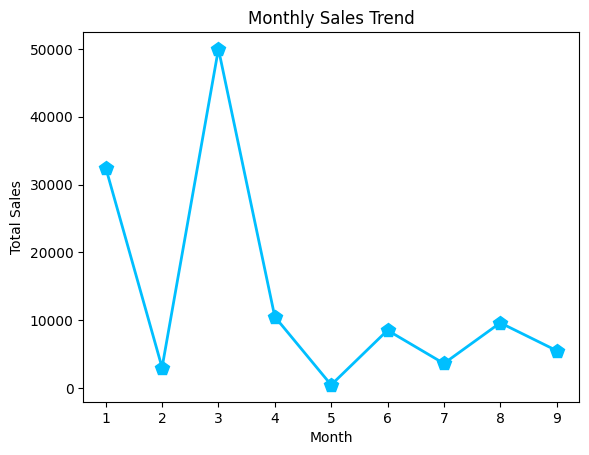

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.month)['total'].sum()
monthly_sales.plot(kind='line', marker='p', color='#00bfff', markersize=10, linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()